# Assignment 4

In [45]:
#All imported libraries listed here
import sys
import gzip
import shutil

import numpy as np

import pandas as pd

import mlflow
from mlflow.tracking import MlflowClient

import joblib

import torch
import torch.nn as nn

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Below we import the class file for the neural network, it was found that MLflow does not serialize ipynb cells properly thus a global class definition in models was needed in a .py file.

In [46]:
from models.regression_nn import RegressionNeuralNetwork #This is the class needed for the neural network

## Part 1: Experiment Tracking with MLflow

### Task 1.1: MLflow Setup & Experiment Logging

#### Setting Up The MLflow Server and Configs

In [47]:
#Run 'mlflow ui --port 5000' to access the server before running this code

mlflow.set_tracking_uri("http://localhost:5000") #The tracking server for MLflow
mlflow.set_experiment("taxi-tip-prediction") #The experiment we will connect to

2026/04/17 01:36:35 INFO mlflow.tracking.fluent: Experiment with name 'taxi-tip-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/mlflow/artifacts/1', creation_time=1776404195316, experiment_id='1', last_update_time=1776404195316, lifecycle_stage='active', name='taxi-tip-prediction', tags={}, trace_location=None, workspace='default'>

#### Loading the Random Forest Regressor Model

In [48]:
#Loading our pretrained Random Forest Regressor
try:
    rf_model = joblib.load("models/rf_regressor.joblib")
except Exception as e:
    print("Error: ", e)
    sys.exit(1)

print("Random Forest Regressor Model has been loaded successfully")

Random Forest Regressor Model has been loaded successfully


#### Loading The Neural Network Regression Model

We then load in the neural network along with the configs

In [49]:
#Loading the neural network
try:
    checkpoint = torch.load('models/nn_regressor.pth')

    # Recreate architecture using saved config
    nn_model = RegressionNeuralNetwork(checkpoint['input_size'])
    nn_model.load_state_dict(checkpoint['model_state_dict'])
    nn_model.eval() #Switch the model to evaluation mode
except Exception as e:
    print("Error: ", e)
    sys.exit(1)    
    

print("Nueral Network Model has been loaded successfully")

Nueral Network Model has been loaded successfully


#### Running The Experiment For Random Forest Regressor 

In [50]:
#Loading in the data needed for the experiment
try:
    X_test = pd.read_csv("data/X_test.csv.gz")
    y_test = pd.read_csv("data/Y_test.csv.gz").squeeze()
except Exception as e:
    print("Error: ", e)
    sys.exit(1)

print("Test data loaded successfully for experiment")

Test data loaded successfully for experiment


In [51]:
#Helper function for repeated experiment logging and metadata
def log_metrics_and_metadata(model, modelName, preds):

    #Logging required metrics
    mlflow.log_metric("mae", mean_absolute_error(y_test, preds))
    mlflow.log_metric("rmse", np.sqrt(mean_squared_error(y_test, preds)))
    mlflow.log_metric("r2", r2_score(y_test, preds))

    mlflow.set_tag("model_type", modelName)
    mlflow.set_tag("dataset_version", "v1")
    mlflow.set_tag("author", "Arvesh")

In [52]:
#Running experiment for Random Forest Regressor
with mlflow.start_run(run_name="random-forest-regressor"):
    print("Beginning experiment for Random Forest Regressor Model")

    mlflow.log_params({
        "n_estimators": 200,
        "max_depth": 5, 
        "random_state": 42
    }) #Log the parameters for the model

    preds = rf_model.predict(X_test) #Evaluate the data on the X Test data
    log_metrics_and_metadata(rf_model, "Random Forest Regressor", preds)

    mlflow.sklearn.log_model(rf_model, "model") #Log the model itself to the MLflow server
    print(f"Run logged for model Random Forest Regressor ! Check the MLflow UI.\n")

Beginning experiment for Random Forest Regressor Model


2026/04/17 01:37:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 01:37:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged for model Random Forest Regressor ! Check the MLflow UI.

🏃 View run random-forest-regressor at: http://localhost:5000/#/experiments/1/runs/540a0fa97d0c4a9f824f489eecdb3375
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [53]:
#Running experiment for Neural Network Regression Model
with mlflow.start_run(run_name="neural-network-regression"):
    print("Beginning experiment for Neural Network Regression Model")

    mlflow.log_params({
        "input_size": 10, 
        "hidden_sizes": str([128, 64]), 
        "dropout_rate": 0.3
    }) #Log the parameters for the model

    #The test data might have NaNs so we replace them with 0s
    #This is done to calculate the metrics without error
    X_test = X_test.fillna(0)

    X_tensor = torch.FloatTensor(X_test.values.astype(float)) #Convert X test into a tensor

    with torch.no_grad():
        preds = nn_model(X_tensor).numpy().flatten()

    log_metrics_and_metadata(nn_model, "Neural Network Regression", preds)
    
    mlflow.pytorch.log_model(nn_model, "model") # Log the model itself to the MLflow server
    print(f"Run logged for model Neural Network Regression ! Check the MLflow UI.\n")

Beginning experiment for Neural Network Regression Model


2026/04/17 01:38:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 01:38:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Run logged for model Neural Network Regression ! Check the MLflow UI.

🏃 View run neural-network-regression at: http://localhost:5000/#/experiments/1/runs/a48fa063cb6f4788846b0fa78698ad0e
🧪 View experiment at: http://localhost:5000/#/experiments/1


#### UI Screenshot of Runs

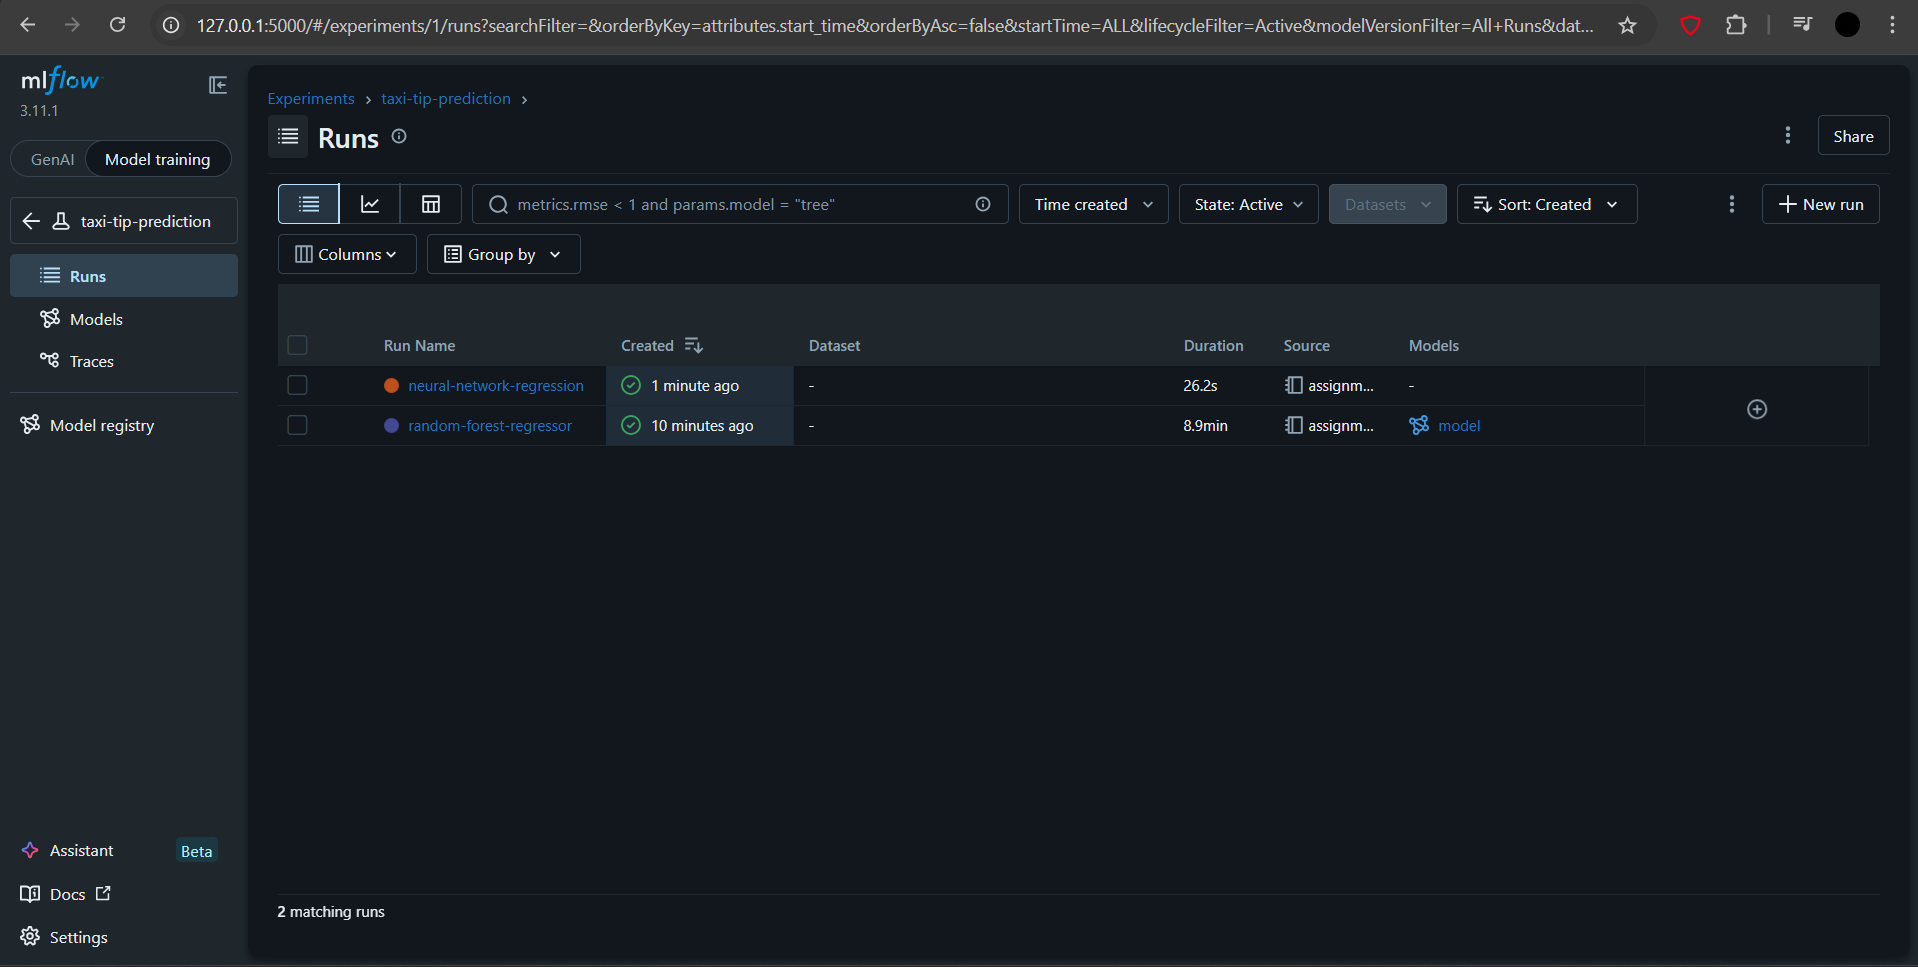

### Task 1.2: Model Comparison & Registry

#### Experiment Screenshots

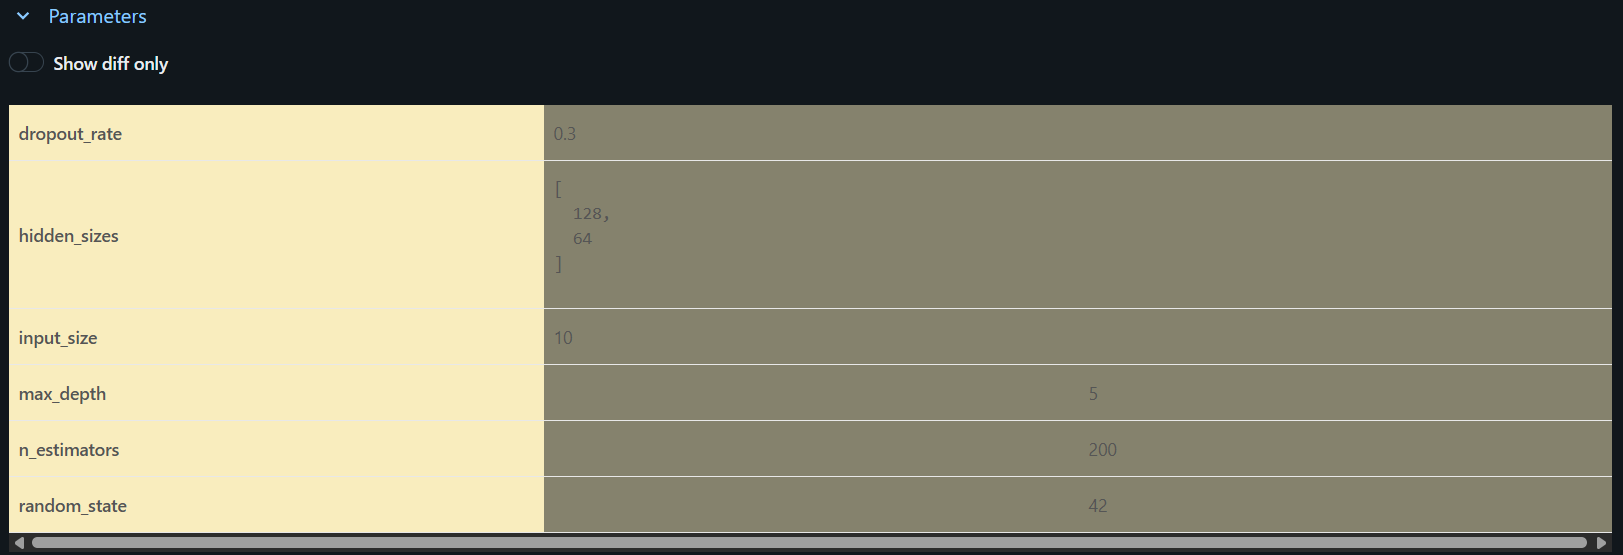

Below, the left is the Neural Network while the right is the Random Forest Regressor

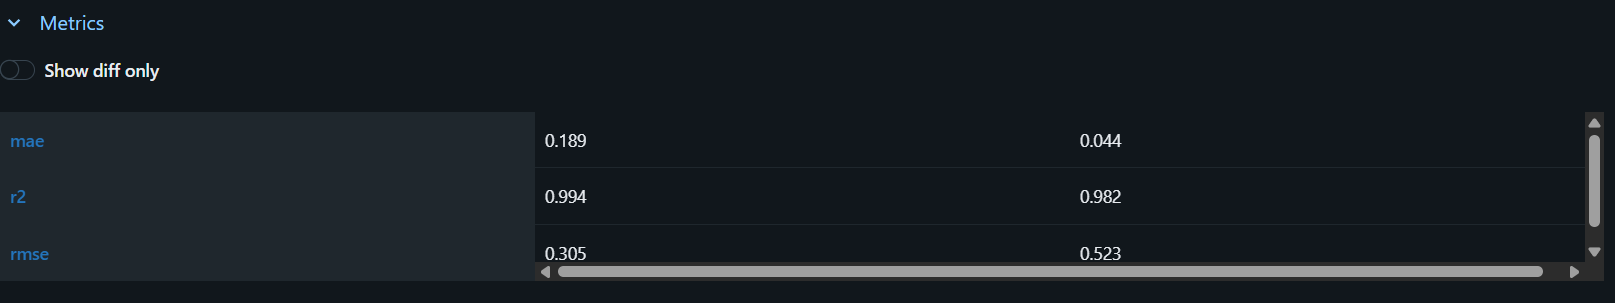

#### Explaining The Metrics

The NN model performed better with a lower RMSE score of 0.305 compared to the RF model's score of 0.523 and a higher R2 score of 0.994 compared to 0.982 which explains better variance. However the RF model had a lower MAE of 0.044 comapred to the NN 0.189 with there being less errors on average. This happened due to how constrained the RF model was with a max depth of only 5 while the NN is less constrained.

#### Registering the Best Performing Model

In [54]:
#Getting the best performing model from MLflow

client = MlflowClient() # Get the client

experiment = client.get_experiment_by_name("taxi-tip-prediction") #Get our experiment

#Search our runs and get the top performing run by RMSE in ascending order
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.RMSE ASC"], #ASC makes it be ascending
    max_results=1 #Get top result
)

best_run = runs[0] #Get the top result from array(only has one value eitherway)
BEST_MODEL_RUN_ID = best_run.info.run_id #Get the run ID

print(f"Best run ID: {BEST_MODEL_RUN_ID} \n")
print(f"RMSE:        {best_run.data.metrics['rmse']}")
print(f"MAE:         {best_run.data.metrics['mae']}")
print(f"R2:          {best_run.data.metrics['r2']}")

Best run ID: a48fa063cb6f4788846b0fa78698ad0e 

RMSE:        0.3047744577723812
MAE:         0.18875961616425008
R2:          0.993782899432251


In [55]:
result = mlflow.register_model(
    model_uri=f"runs:/{BEST_MODEL_RUN_ID}/model",
    name="taxi-tip-regressor"
)

#Adding version and description to the model
client.update_model_version(
    name="taxi-tip-regressor",
    version= result.version,
    description=(
        f"Best performing model: Neural Network Regression. "
        f"MAE: {best_run.data.metrics['mae']}, "
        f"RMSE: {best_run.data.metrics['rmse']}, "
        f"R2: {best_run.data.metrics['r2']}. "
        f"Trained on NYC taxi dataset for Jan 2024."
    )
)

print("Model registered successfully with MLflow Model Registry !")

Successfully registered model 'taxi-tip-regressor'.
2026/04/17 01:38:35 WARNING mlflow.tracking._model_registry.fluent: Run with id a48fa063cb6f4788846b0fa78698ad0e has no artifacts at artifact path 'model', registering model based on models:/m-a809e5cf46bc48c6a632b7ba6d243b5e instead
2026/04/17 01:38:36 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: taxi-tip-regressor, version 1
Created version '1' of model 'taxi-tip-regressor'.


Model registered successfully with MLflow Model Registry !


#### Evaluating The Model On Unseen Data

In [56]:
best_model = mlflow.pytorch.load_model(f"models:/taxi-tip-regressor/{result.version}") #Loads the latest version of the model registered
best_model.eval() #Set to eval mode
print("Best model loaded successfully from MLflow Model Registry !")

print("\nAttempting to load new data for prediction with registered model...")
try:
    X_new = pd.read_csv("data/X_val.csv.gz") #Read new data for registered model to predict on
    Y_new = pd.read_csv("data/Y_val.csv.gz").squeeze() #Read new labels for registered model to eval on
except Exception as e:
    print("Error: ", e)
    sys.exit(1)

print("New data loaded successfully for prediction with registered model")

print("\nMaking predictions with the registered model on new data...")

#Earlier code to fill NaNs with 0s and conver to tensor
X_new = X_new.fillna(0)
X_tensor = torch.FloatTensor(X_new.values.astype(float)) #Convert X new into a tensor
with torch.no_grad():
    prediction = best_model(X_tensor).numpy()


print("\nSample predictions vs actual values:")
results = pd.DataFrame({
    "predicted_tip": prediction.flatten(),
    "actual_tip":    Y_new.values
})
print(results)

Best model loaded successfully from MLflow Model Registry !

Attempting to load new data for prediction with registered model...
New data loaded successfully for prediction with registered model

Making predictions with the registered model on new data...

Sample predictions vs actual values:
        predicted_tip  actual_tip
0            1.145751        1.00
1            4.241258        4.20
2            3.621804        3.64
3            3.078744        3.00
4            2.673649        2.73
...               ...         ...
344757       2.671869        2.37
344758       5.202228        5.35
344759       3.347797        3.30
344760       3.028935        3.08
344761       3.177369        3.00

[344762 rows x 2 columns]


## Part 2 Docs Fast API Docs

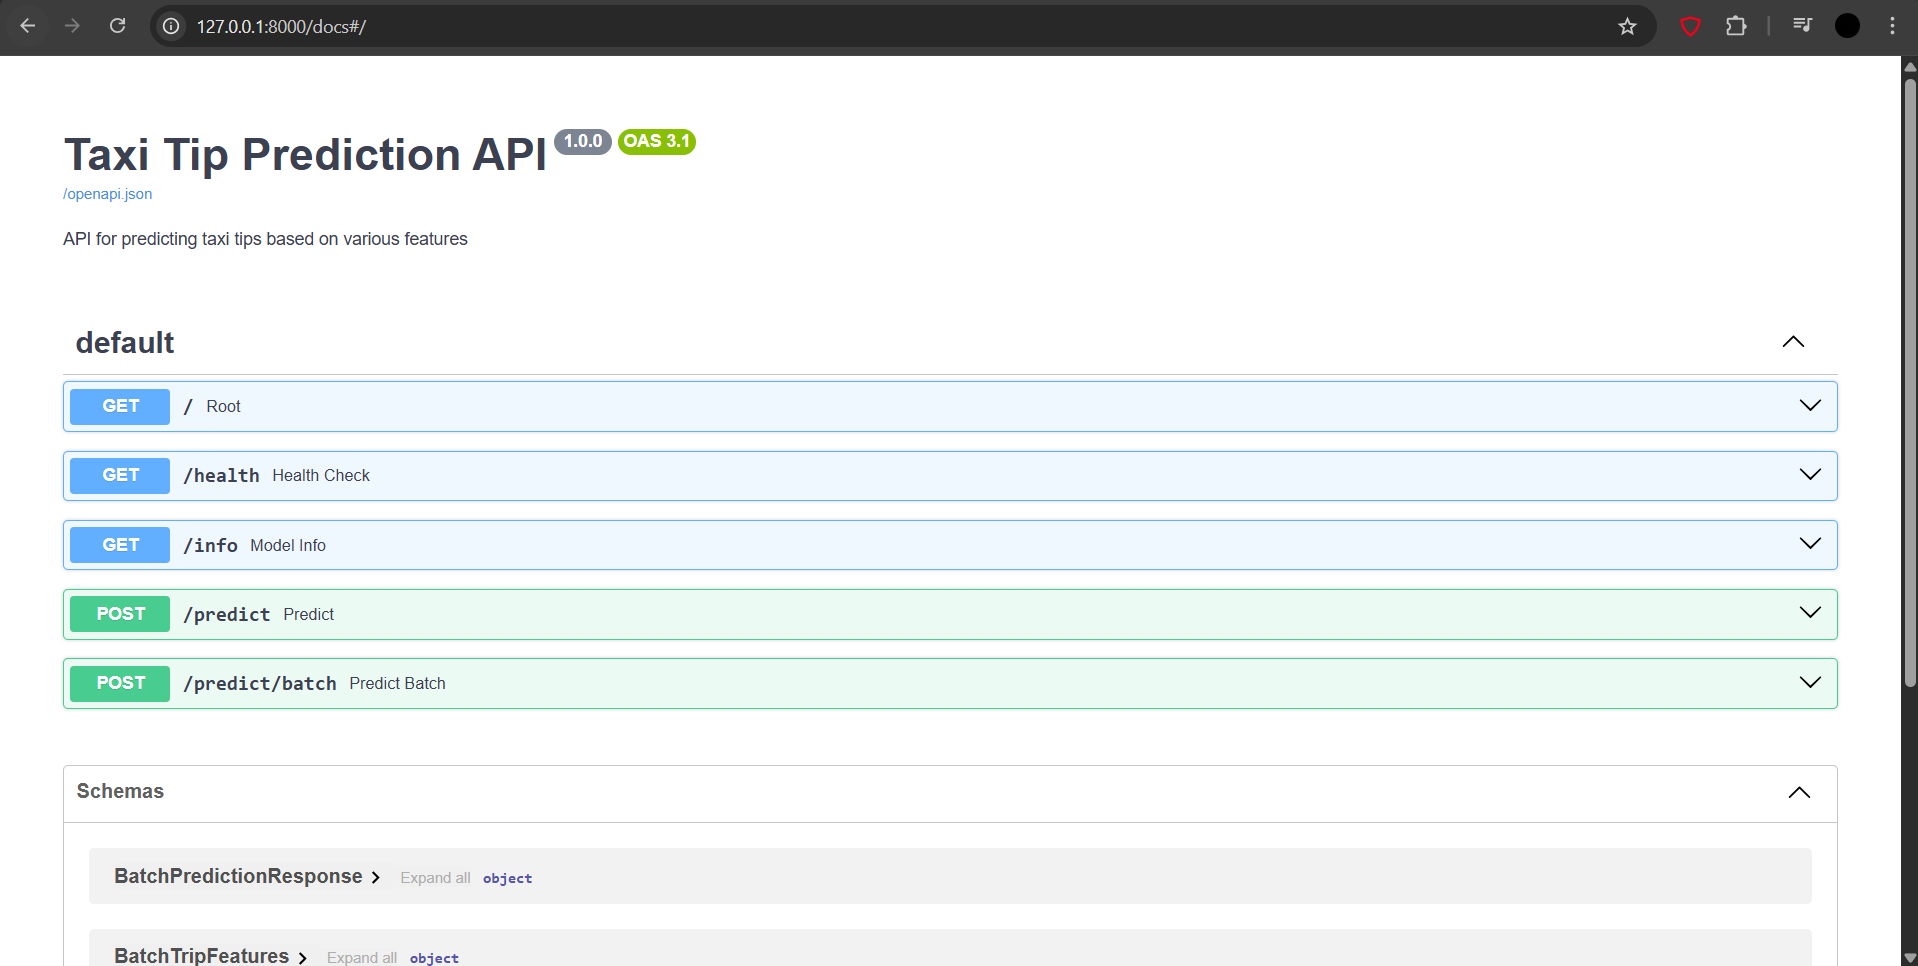

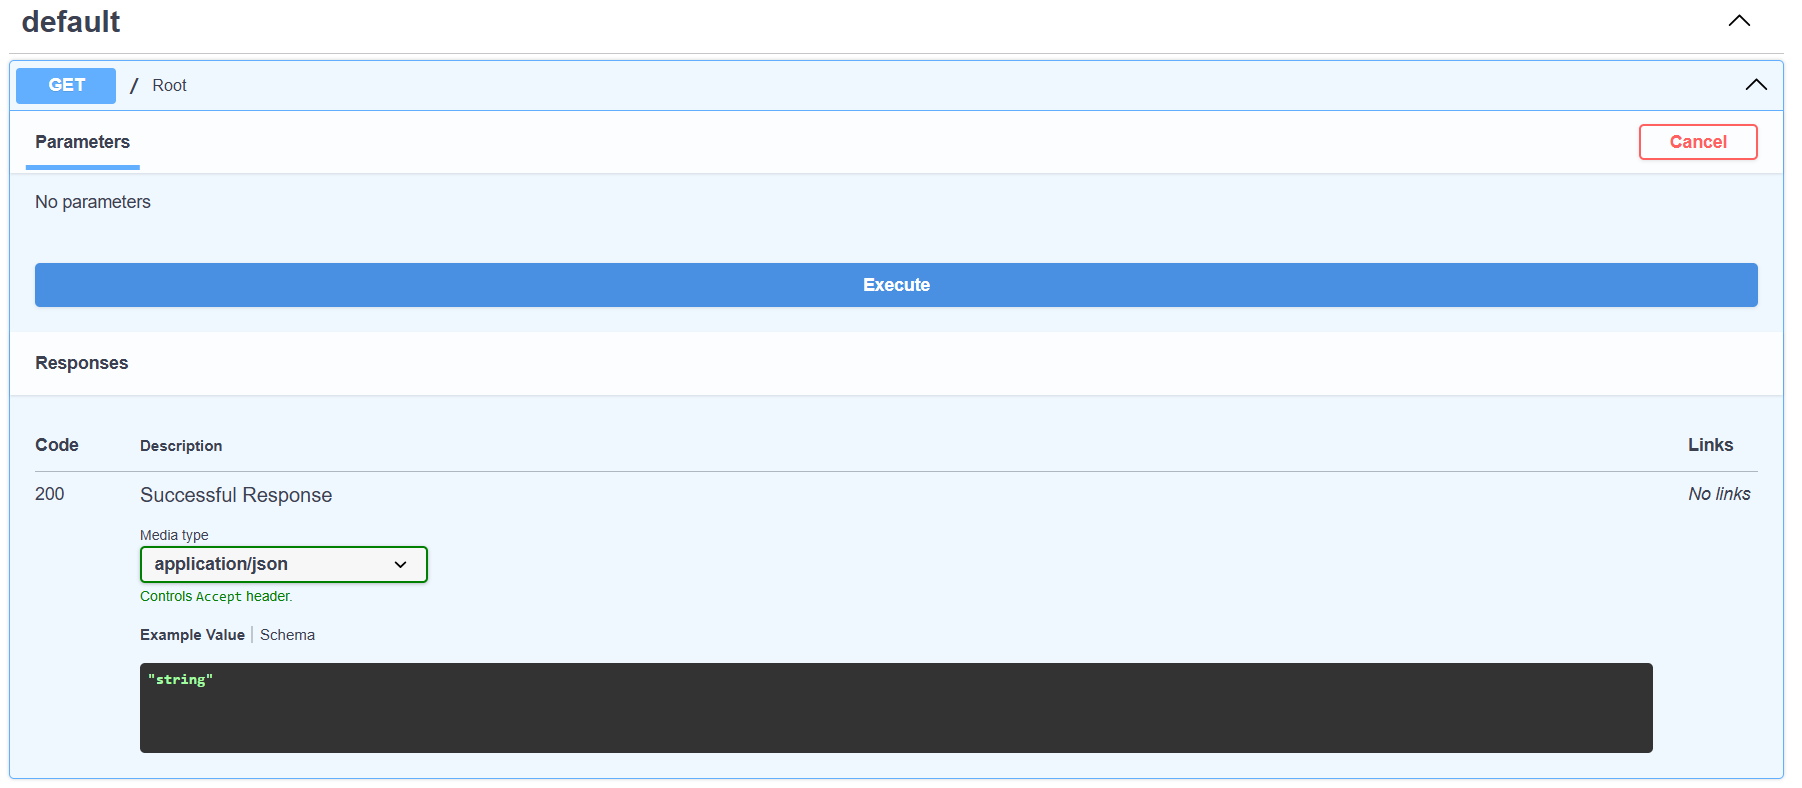

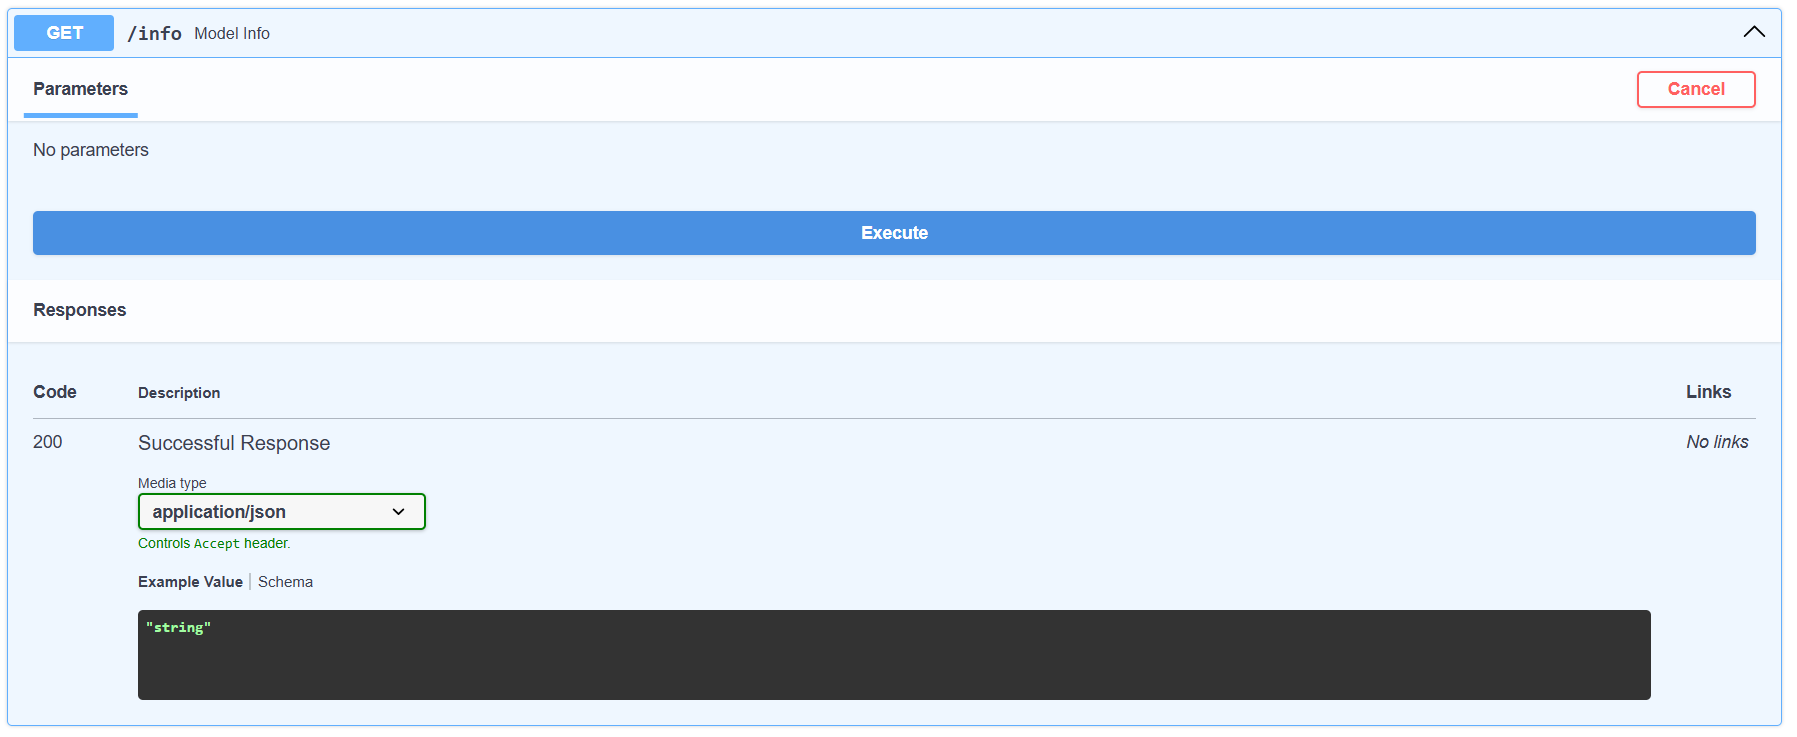

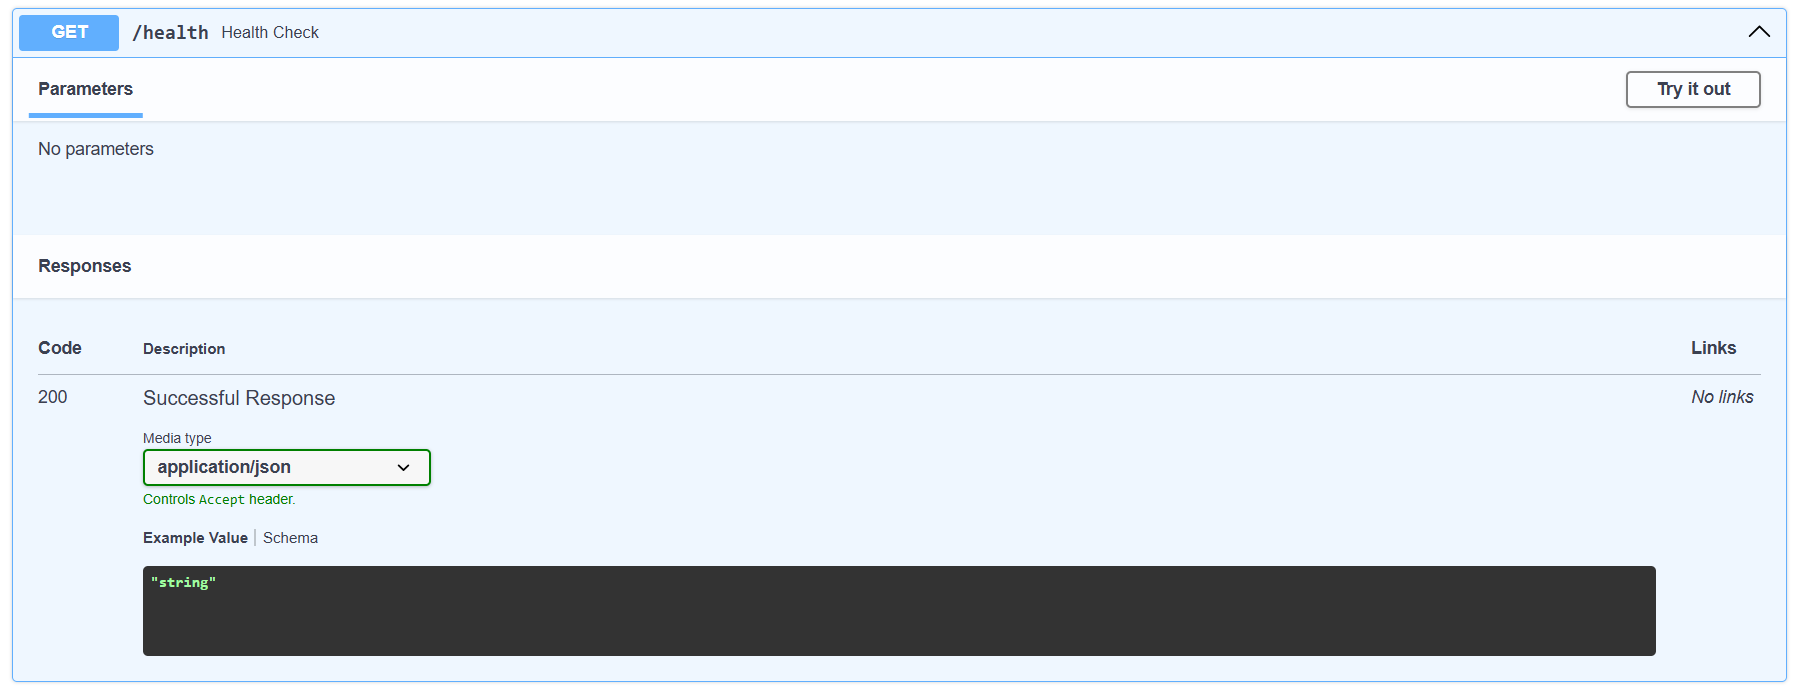

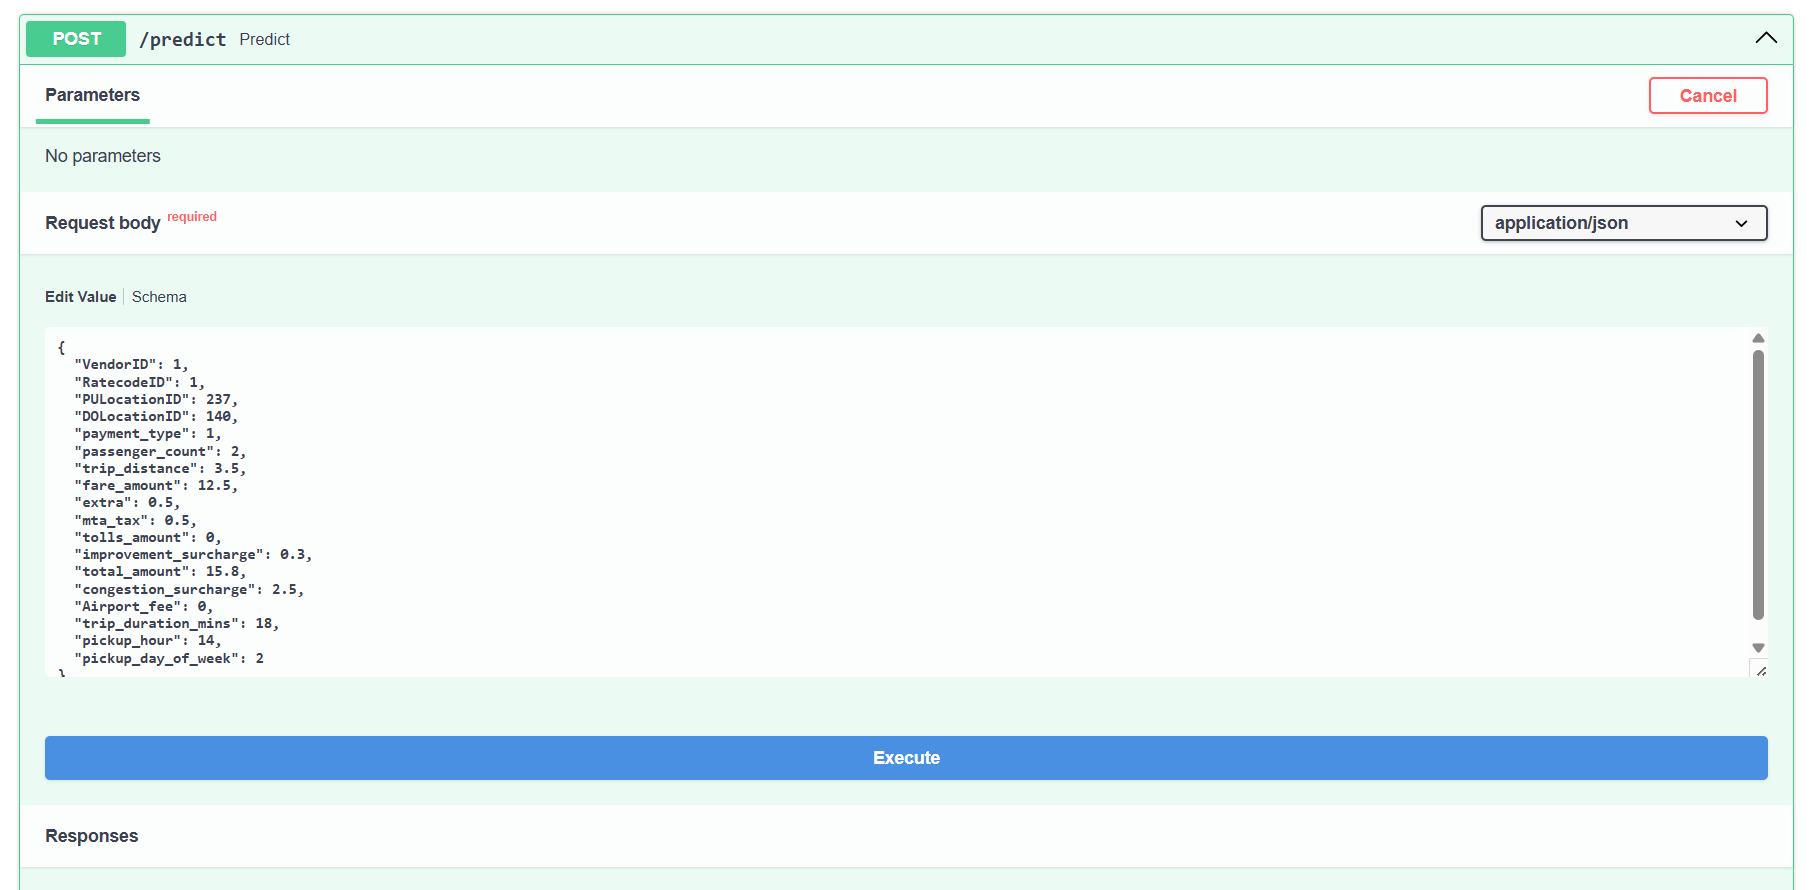

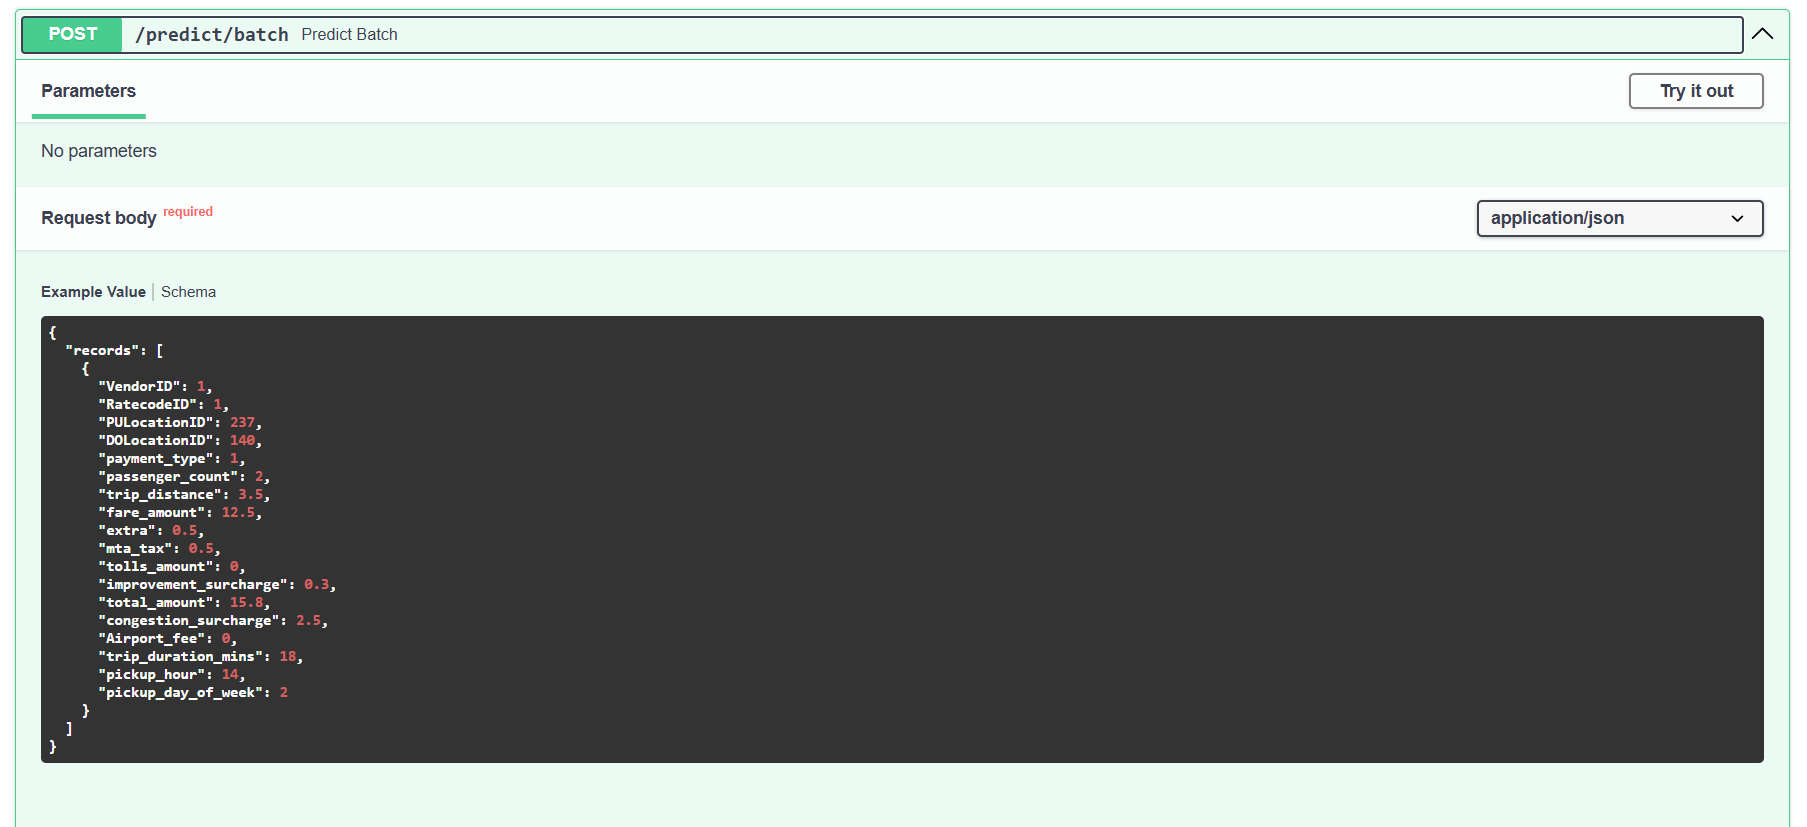

### Tests

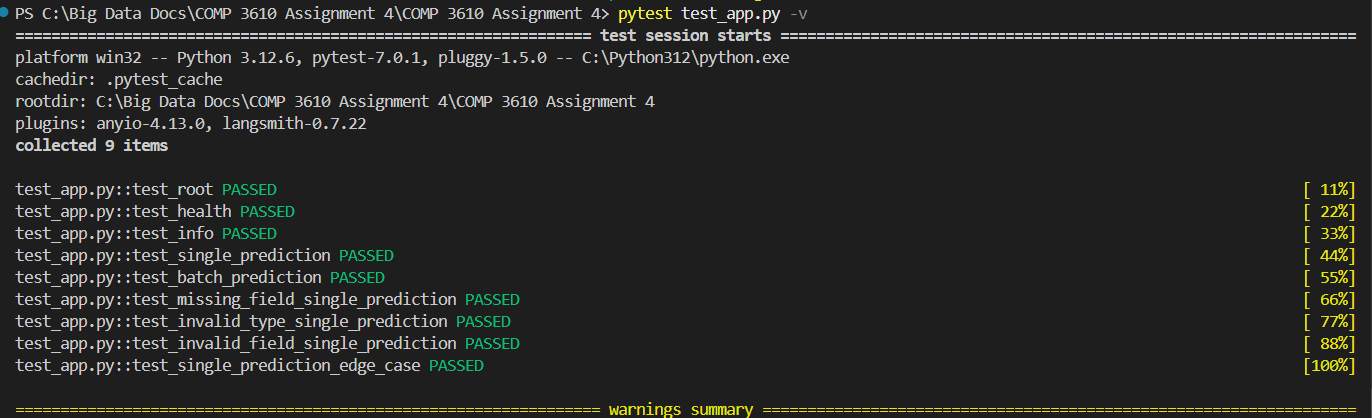

## Part 3 Documentation (More images in Image Folder)

### Docker Image Size

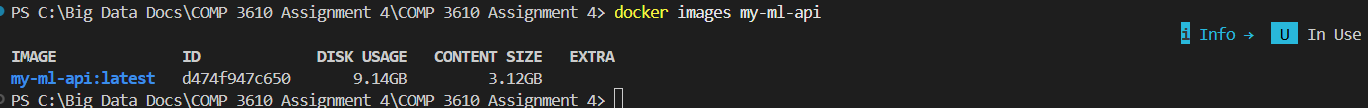

### Docker Health Check

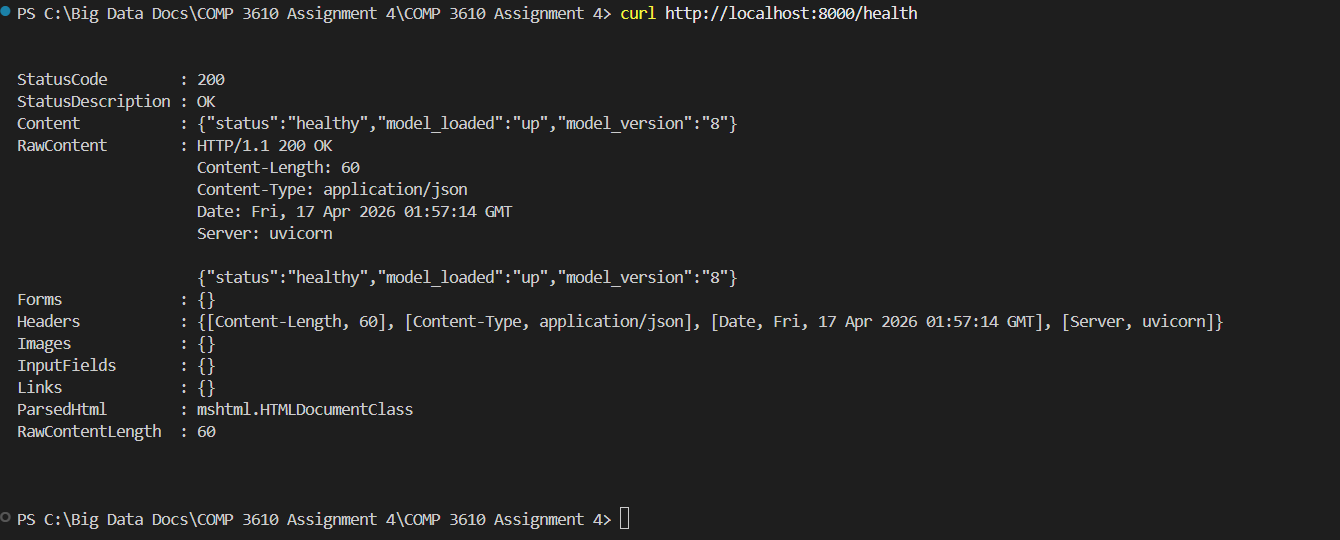

### Docker Compose Build

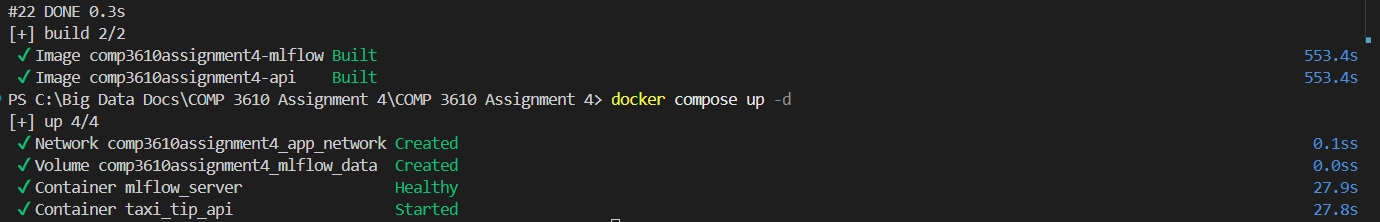

### Docker Compose Services

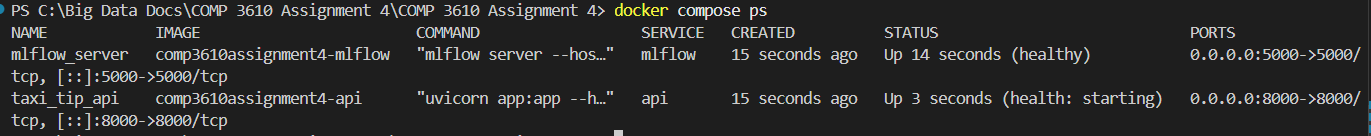

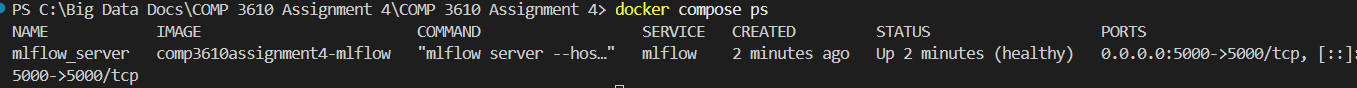

### Docker Compose Down

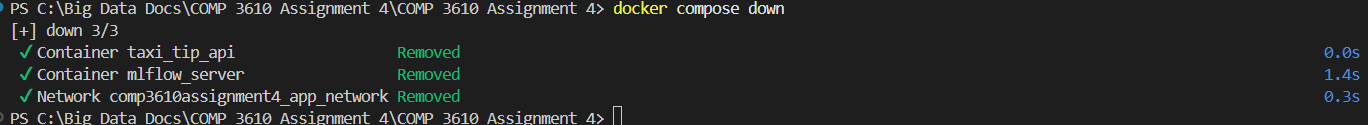

Test prediction request to MLFlow API Docker Container 

In [4]:
import requests

response = requests.post("http://localhost:8000/predict", json={
    "VendorID": 1,
    "RatecodeID": 1,
    "PULocationID": 237,
    "DOLocationID": 140,
    "payment_type": 1,
    "passenger_count": 2,
    "trip_distance": 3.5,
    "fare_amount": 12.50,
    "extra": 0.5,
    "mta_tax": 0.5,
    "tolls_amount": 0.0,
    "improvement_surcharge": 0.3,
    "total_amount": 15.80,
    "congestion_surcharge": 2.5,
    "Airport_fee": 0.0,
    "trip_duration_mins": 18.0,
    "pickup_hour": 14,
    "pickup_day_of_week": 2
})

print(response.status_code)
print(response.json())

200
{'predicted_tip_amount': 2.69, 'prediction_id': '53faaf91-97b5-4189-a50f-a4738bd23708', 'model_version': '1'}
